# Data Cleaning

Source: OpenAlex API, 5000 works with at least one Ukrainian affiliation,
published 2018–2024, in a single research field (concept C162324750).

Goal of this notebook: profile the raw data, identify quality issues,
and produce a cleaned panel suitable for analysis.

In [1]:
import os
print("CWD:", os.getcwd())
print("Files here:", os.listdir())

CWD: C:\Users\sofia\Documents\ua-science-diaspora\notebooks
Files here: ['.ipynb_checkpoints', '01_cleaning.ipynb', '02_analysis.ipynb']


In [2]:
import sqlite3
import pandas as pd

con = sqlite3.connect("../data/clean/works.db")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. What is in this dataset?

Before any cleaning, I check what we actually downloaded.
The concept ID was chosen as a proxy for "economics", but I should verify.

In [3]:
top_concepts = pd.read_sql("""
    SELECT primary_concept, COUNT(*) AS n
    FROM works
    WHERE primary_concept IS NOT NULL
    GROUP BY primary_concept
    ORDER BY n DESC
    LIMIT 15
""", con)
top_concepts

,primary_concept,n
0,Business,180
1,Ukrainian,178
2,Physics,143
3,Computer science,118
4,Sustainable development,105
5,Renewable energy,97
6,Medicine,92
7,Tourism,78
8,Mathematics,75
9,Agriculture,70


**Finding 1.** The concept filter C162324750 turned out to be poorly specific —
the top primary concepts are Business (180), "Ukrainian" (178), Physics (143),
Computer Science (118), with Economics only 14th (48 works). OpenAlex concepts
are deprecated and known to be noisy.

**Decision.** Rather than discard the sample, I reframe the research question
from "Ukrainian economists" to "Ukrainian researchers across fields". This
is honest given the data and arguably more interesting for diaspora analysis.

**Finding 2.** Works per year: clear drop after 2022 (full-scale invasion).
2024 partial.

**Finding 3.** Missingness: ORCID 31%, country 5%, institution 4%, author_id 2%.
ORCID coverage is fine for a subsample-based deduplication strategy.

In [4]:
overview = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM works) AS n_works,
        (SELECT COUNT(*) FROM authorships) AS n_authorships,
        (SELECT COUNT(DISTINCT author_id) FROM authorships WHERE author_id IS NOT NULL) AS n_unique_authors,
        (SELECT COUNT(DISTINCT institution_id) FROM authorships WHERE institution_id IS NOT NULL) AS n_unique_institutions,
        (SELECT MIN(year) FROM works) AS min_year,
        (SELECT MAX(year) FROM works) AS max_year
""", con)
overview

,n_works,n_authorships,n_unique_authors,n_unique_institutions,min_year,max_year
0,5000,51435,20151,4444,2018,2024


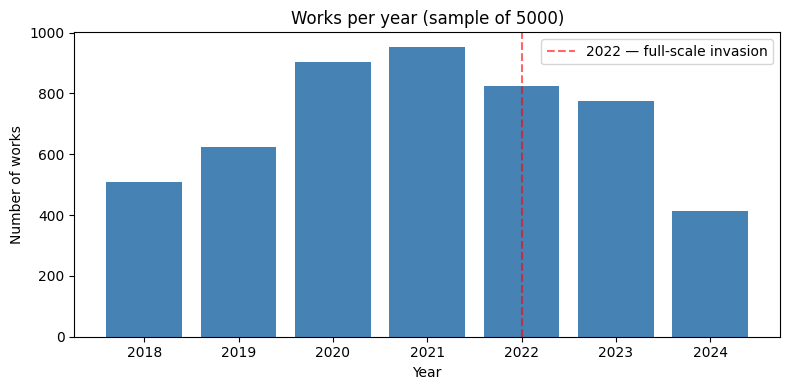

In [5]:
import matplotlib.pyplot as plt

by_year = pd.read_sql("SELECT year, COUNT(*) AS n FROM works GROUP BY year ORDER BY year", con)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_year["year"], by_year["n"], color="steelblue")
ax.axvline(2022, color="red", linestyle="--", alpha=0.6, label="2022 — full-scale invasion")
ax.set_xlabel("Year"); ax.set_ylabel("Number of works"); ax.legend()
ax.set_title("Works per year (sample of 5000)")
plt.tight_layout(); plt.show()

In [6]:
nulls = pd.read_sql("""
    SELECT
        SUM(author_id IS NULL) AS missing_author_id,
        SUM(orcid IS NULL) AS missing_orcid,
        SUM(institution_id IS NULL) AS missing_institution,
        SUM(country_code IS NULL) AS missing_country,
        COUNT(*) AS total_rows
    FROM authorships
""", con)
nulls

,missing_author_id,missing_orcid,missing_institution,missing_country,total_rows
0,1080,15966,2205,2585,51435


## 2. Deduplicating authors

Each author can appear in many works. To track migration, I need a clean
author × year × country panel. The deduplication strategy:

1. Drop rows without `author_id` (cannot trace those).
2. Drop rows without `country_code` (cannot infer location).
3. For authors with the same `author_id`, OpenAlex already disambiguates —
   I trust the ID as the join key.
4. ORCID is checked but not required (only 69% coverage).

In [7]:
df = pd.read_sql("""
    SELECT a.author_id, a.author_name, a.orcid,
           a.institution_id, a.institution_name, a.country_code,
           w.year, w.work_id, w.primary_concept
    FROM authorships a
    JOIN works w ON a.work_id = w.work_id
    WHERE a.author_id IS NOT NULL
      AND a.country_code IS NOT NULL
""", con)
print("rows after dropping NULLs:", len(df))
print("unique authors:", df["author_id"].nunique())
df.head()

rows after dropping NULLs: 48063
unique authors: 18898


,author_id,author_name,orcid,institution_id,institution_name,country_code,year,work_id,primary_concept
0,https://openalex.org/A5084002697,Alexei Botchkarev,https://orcid.org/0000-0002-0689-8830,https://openalex.org/I90281761,National Aviation University,UA,2019,https://openalex.org/W3105640742,Computer science
1,https://openalex.org/A5084002697,Alexei Botchkarev,https://orcid.org/0000-0002-0689-8830,https://openalex.org/I530967,Toronto Metropolitan University,CA,2019,https://openalex.org/W3105640742,Computer science
2,https://openalex.org/A5050568340,Yevhen Maltsev,https://orcid.org/0000-0003-4710-319X,https://openalex.org/I4210133056,Timiryazev Institute of Plant Physiology,RU,2021,https://openalex.org/W3207525128,Carotenoid
3,https://openalex.org/A5021051017,Kateryna Maltseva,https://orcid.org/0000-0002-0753-4369,https://openalex.org/I4210104452,Bogdan Khmelnitsky Melitopol State Pedagogical...,UA,2021,https://openalex.org/W3207525128,Carotenoid
4,https://openalex.org/A5111886392,Maxim Kulikovskiy,NaN,https://openalex.org/I4210133056,Timiryazev Institute of Plant Physiology,RU,2021,https://openalex.org/W3207525128,Carotenoid


## 3. Normalising institution names

Quick look at the top institutions — same place can appear under several names
(transliteration, translation, abbreviation).

In [8]:
top_inst = (df[df["country_code"] == "UA"]
            .groupby("institution_name").size()
            .sort_values(ascending=False).head(30)
            .reset_index(name="n"))
top_inst

,institution_name,n
0,Sumy State University,1227
1,Lviv Polytechnic National University,646
2,Taras Shevchenko National University of Kyiv,617
3,National Academy of Sciences of Ukraine,506
4,National University of Life and Environmental ...,476
5,West Ukrainian National University,365
6,Kyiv National Economic University named after ...,306
7,State University of Trade and Economics,289
8,Lviv University,269
9,Vinnytsia National Agrarian University,260


**Decision.** The top 30 Ukrainian institutions don't show obvious duplicate
naming (OpenAlex appears to handle Ukrainian transliteration variants
internally). I'll trust `institution_id` and skip manual mapping for the
demo. In a full project, fuzzy matching on names + comparison with the
ROR database would be the next step.

## 4. Building the author × year × country panel

For each author–year pair, identify the country of their primary affiliation.
If an author has affiliations in multiple countries in the same year, keep
all of them (we'll flag "dual affiliation" cases in analysis).

In [9]:
panel = (df.groupby(["author_id", "author_name", "year", "country_code"])
         .size().reset_index(name="n_works"))
print("panel rows:", len(panel))
panel.head()

panel rows: 29162


,author_id,author_name,year,country_code,n_works
0,https://openalex.org/A5000004161,Małgorzata Ulewicz,2020,PL,1
1,https://openalex.org/A5000004691,Carl A. Latkin,2020,US,2
2,https://openalex.org/A5000005327,V. S. Romanyuk,2019,UA,1
3,https://openalex.org/A5000005327,V. S. Romanyuk,2023,UA,2
4,https://openalex.org/A5000005426,Tkachuk Svitlana,2024,UA,1


In [10]:
panel.to_parquet("../data/clean/author_year_country.parquet")
print("saved:", "../data/clean/author_year_country.parquet")

saved: ../data/clean/author_year_country.parquet


## Summary

Cleaned panel saved to `data/clean/author_year_country.parquet`:
- 29,162 rows (author × year × country)
- 18,898 unique authors
- Years 2018–2024
- Countries: any country where a Ukraine-affiliated author also published

Next: `02_analysis.ipynb` uses this panel to answer three questions about
affiliation patterns before and after 2022.